# Stage1 Unified Labels 可视化分析

本 notebook 分析 `data/processed/stage1_unified_labels.csv` 中的人工标注数据，重点观察：

- 数据来源分布：`paper_id`、`source_project`
- 核心标签分布：`root_cause`、`symptom`、`bug_type`、`component`、`fix_type`
- 联合关系：来源 × root cause、来源 × symptom、root cause × symptom、bug type × root cause
- 数据质量：核心字段缺失情况、长尾类别情况

运行后，图表会保存到 `data/processed/stage1_visuals/`，便于写论文或报告时复用。

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'data' / 'processed' / 'stage1_unified_labels.csv'
FIG_DIR = ROOT / 'data' / 'processed' / 'stage1_visuals'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 180
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_csv(DATA_PATH, dtype=str).fillna('')
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

print(DATA_PATH)
print(df.shape)
df.head(3)

D:\AutoEmpirical-Reproduce\data\processed\stage1_unified_labels.csv
(1907, 23)


,record_id,paper_id,source_project,issue_url,title,body,comments,created_at,updated_at,state,...,component,sub_component,trigger_condition,consequence,fix_type,severity_or_impact,original_label_json,source_file,source_sheet,source_row_index
0,ase2021_an_empirical_study_of_bugs:8aaf442b513...,ase2021_an_empirical_study_of_bugs,webassembly_compilers,https://github.com/emscripten-core/emscripten/...,Looks like you are rendering without using req...,,,2019-12-16T00:00:00+00:00,2019-12-21T00:00:00+00:00,,...,Animation,,,,Provide Workaround,,"{""Bug Fix Category"": ""Provide Workaround"", ""Bu...",data/raw_stage1/ase2021_an_empirical_study_of_...,,24
1,ase2021_an_empirical_study_of_bugs:4e927d9e077...,ase2021_an_empirical_study_of_bugs,webassembly_compilers,https://github.com/emscripten-core/emscripten/...,RangeError: start offset of Int32Array should ...,,,2020-01-10T00:00:00+00:00,2020-01-15T00:00:00+00:00,,...,4. Unnecessary Memory Boundary Shifting,,,,Remove shifting functions,,"{""Bug Fix Category"": ""Remove shifting function...",data/raw_stage1/ase2021_an_empirical_study_of_...,,43
2,ase2021_an_empirical_study_of_bugs:239dc26fe31...,ase2021_an_empirical_study_of_bugs,webassembly_compilers,https://github.com/emscripten-core/emscripten/...,acorn-optimizer.js fails with SDL_Init() if O3...,,,2020-01-14T00:00:00+00:00,2020-01-28T00:00:00+00:00,,...,1. Optimizer Removes Symbol,,,,Support missing functions not emitted in stand...,,"{""Bug Fix Category"": ""Support missing function...",data/raw_stage1/ase2021_an_empirical_study_of_...,,73


## 1. 数据概览与质量检查

先看总记录数、来源数、核心标签覆盖率。这里的缺失率会直接影响后续联合分析的可信度。

In [2]:
CORE_COLS = [
    'paper_id', 'source_project', 'symptom', 'root_cause', 'bug_type',
    'component', 'sub_component', 'fix_type', 'severity_or_impact'
]

def nonempty(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().ne('')

quality = []
for col in CORE_COLS:
    filled = int(nonempty(df[col]).sum())
    quality.append({
        'column': col,
        'nonempty': filled,
        'missing': len(df) - filled,
        'coverage': filled / len(df),
        'unique_nonempty': df.loc[nonempty(df[col]), col].nunique(),
    })

quality_df = pd.DataFrame(quality)
quality_df

,column,nonempty,missing,coverage,unique_nonempty
0,paper_id,1907,0,1.000000,8
1,source_project,1907,0,1.000000,8
2,symptom,1869,38,0.980073,186
3,root_cause,1907,0,1.000000,223
4,bug_type,1573,334,0.824856,45
5,component,1603,304,0.840587,112
6,sub_component,422,1485,0.221290,31
7,fix_type,1154,753,0.605139,204
8,severity_or_impact,0,1907,0.000000,0


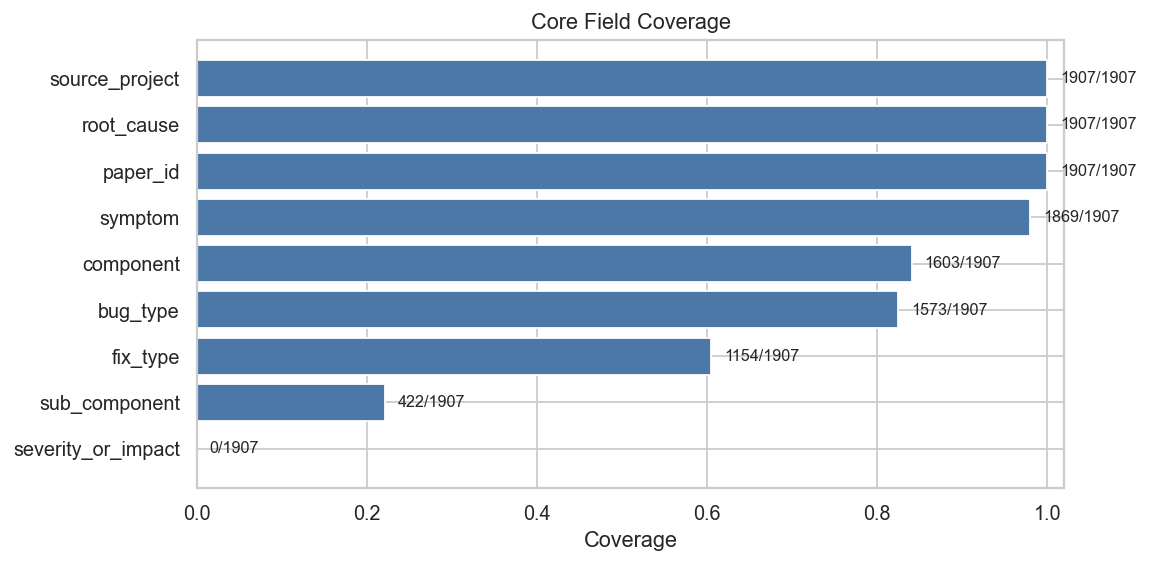

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = quality_df.sort_values('coverage')
ax.barh(plot_df['column'], plot_df['coverage'], color='#4C78A8')
ax.set_xlim(0, 1.02)
ax.set_xlabel('Coverage')
ax.set_title('Core Field Coverage')
for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(row.coverage + 0.015, i, f"{row.nonempty}/{len(df)}", va='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_core_field_coverage.png', bbox_inches='tight')
plt.show()

## 2. 来源分布

不同论文/项目的数据量差异很大。后续跨来源比较时，应该同时看绝对数量和归一化比例。

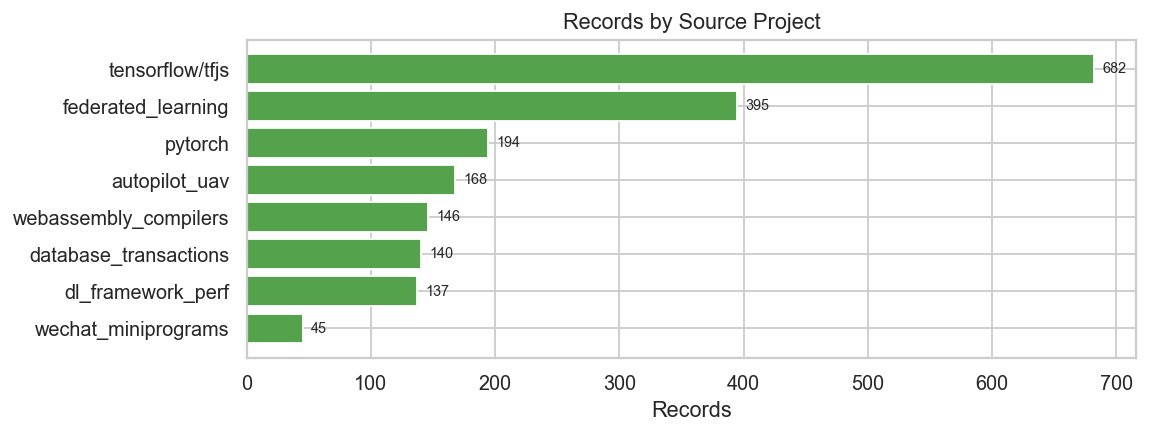

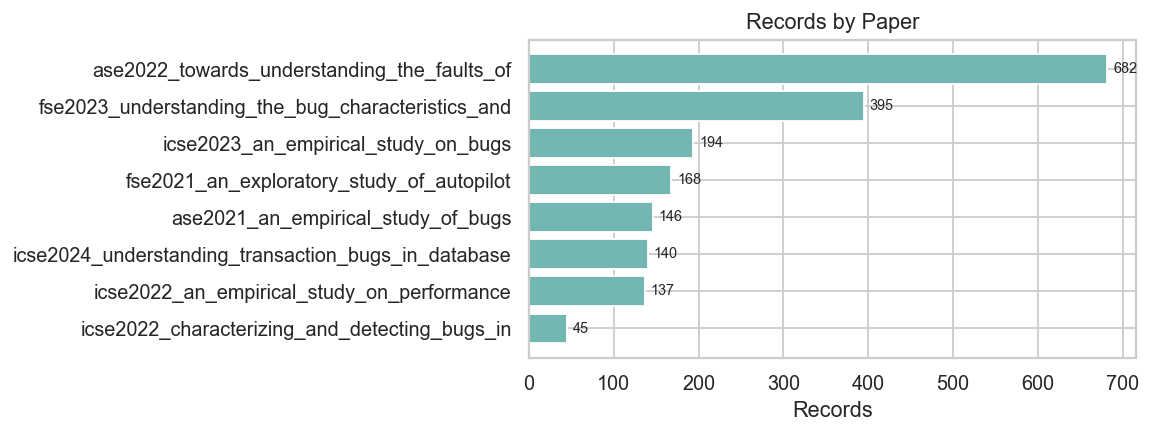

,source_project_count
source_project,
tensorflow/tfjs,682
federated_learning,395
pytorch,194
autopilot_uav,168
webassembly_compilers,146
database_transactions,140
dl_framework_perf,137
wechat_miniprograms,45


In [4]:
def bar_count(series, title, filename, top_n=20, color='#F58518'):
    counts = series[series.astype(str).str.strip().ne('')].value_counts().head(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.38 * len(counts))))
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(title)
    ax.set_xlabel('Records')
    for i, value in enumerate(counts.values):
        ax.text(value + max(counts.values) * 0.01, i, str(value), va='center', fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, bbox_inches='tight')
    plt.show()
    return counts.sort_values(ascending=False)

source_counts = bar_count(df['source_project'], 'Records by Source Project', '02_records_by_source_project.png', color='#54A24B')
paper_counts = bar_count(df['paper_id'], 'Records by Paper', '03_records_by_paper.png', color='#72B7B2')
pd.DataFrame({'source_project_count': source_counts})

## 3. 单变量标签分布

这里先分别看 root cause、symptom、bug type、component、fix type 的 top 类别。长尾标签很多，因此图里只显示 top N。

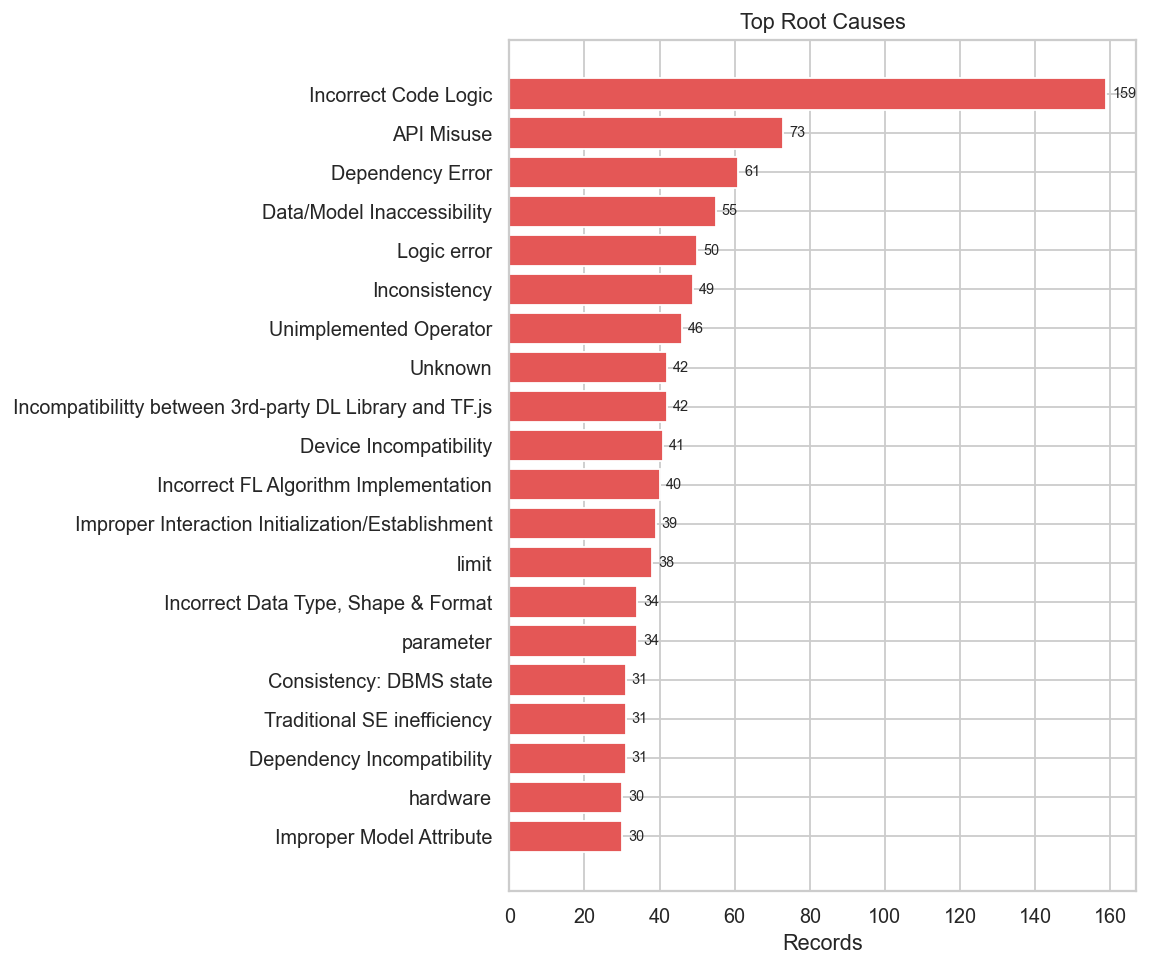

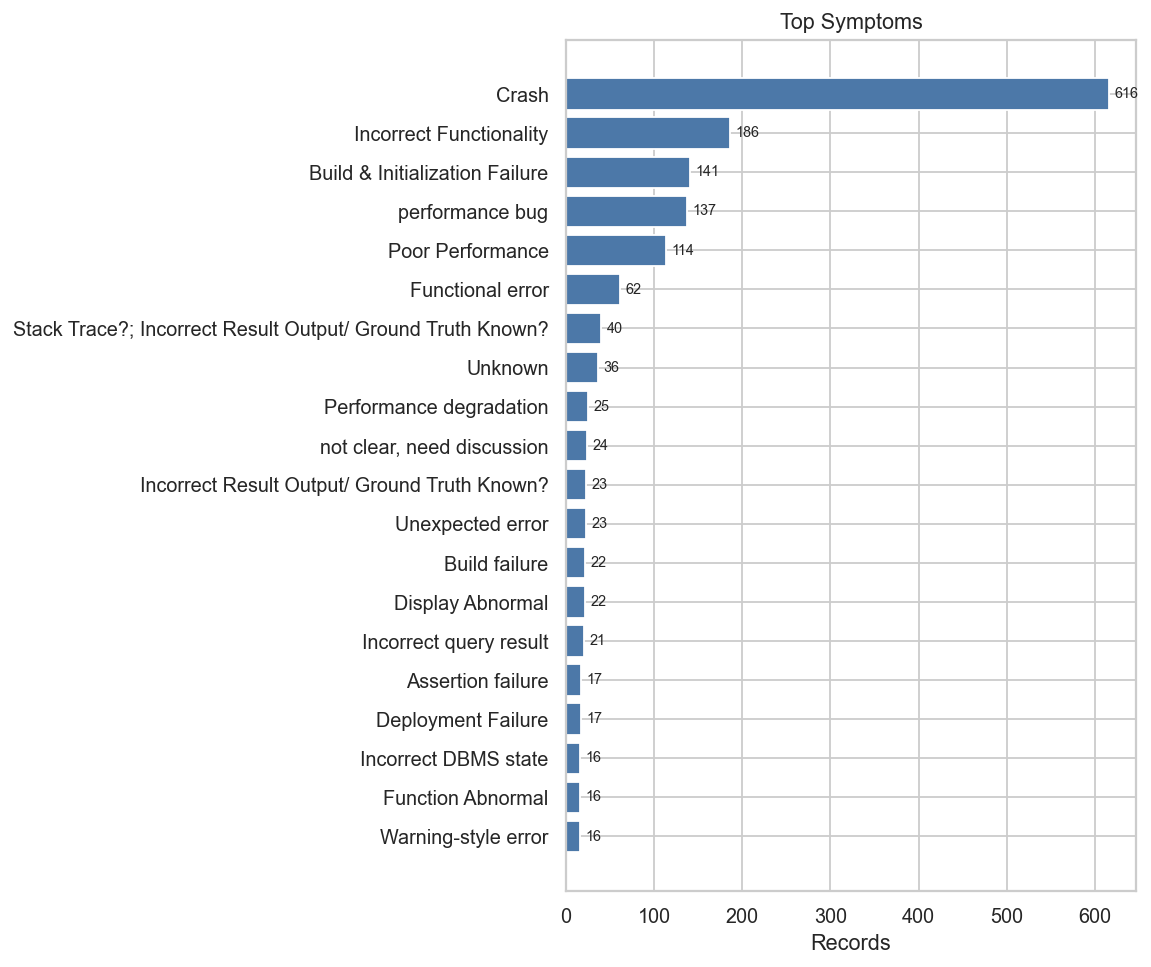

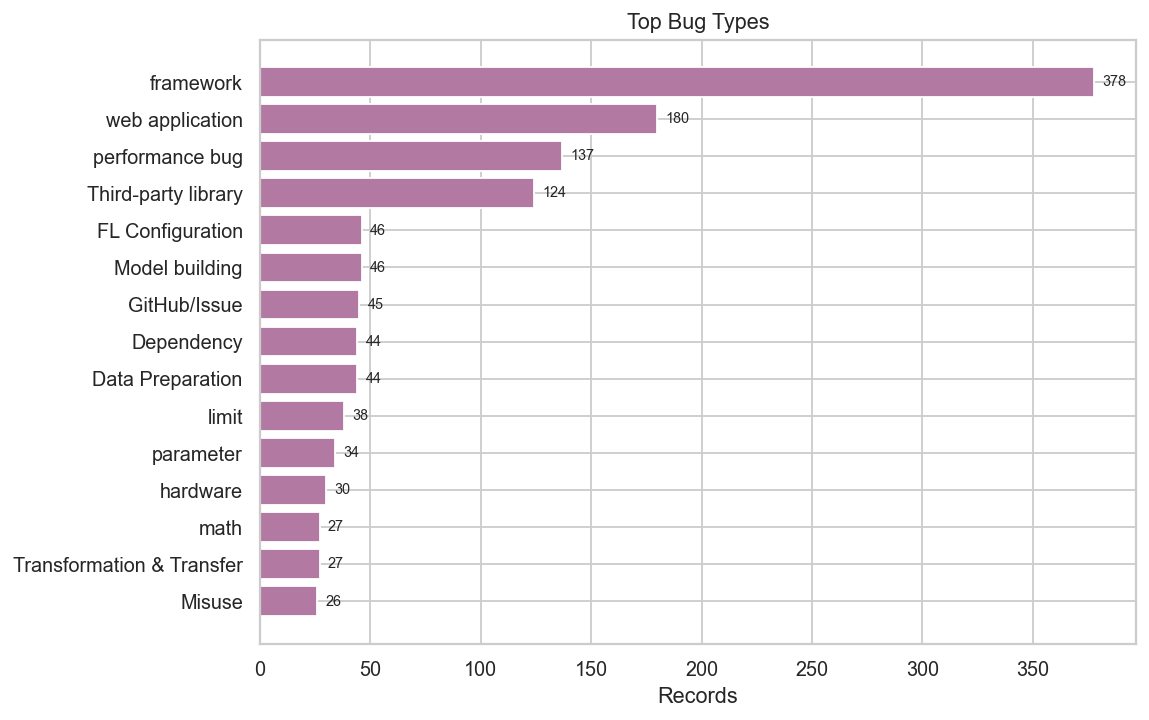

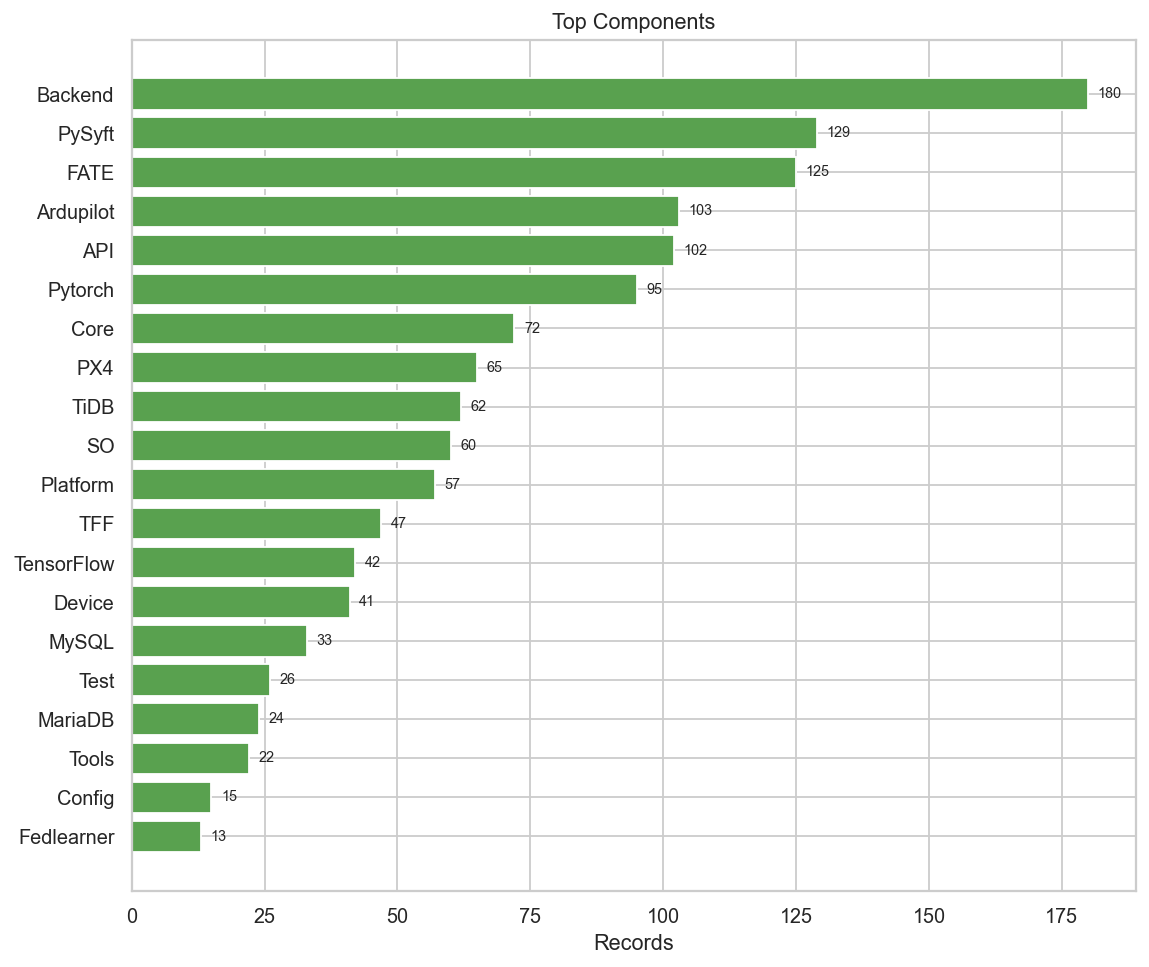

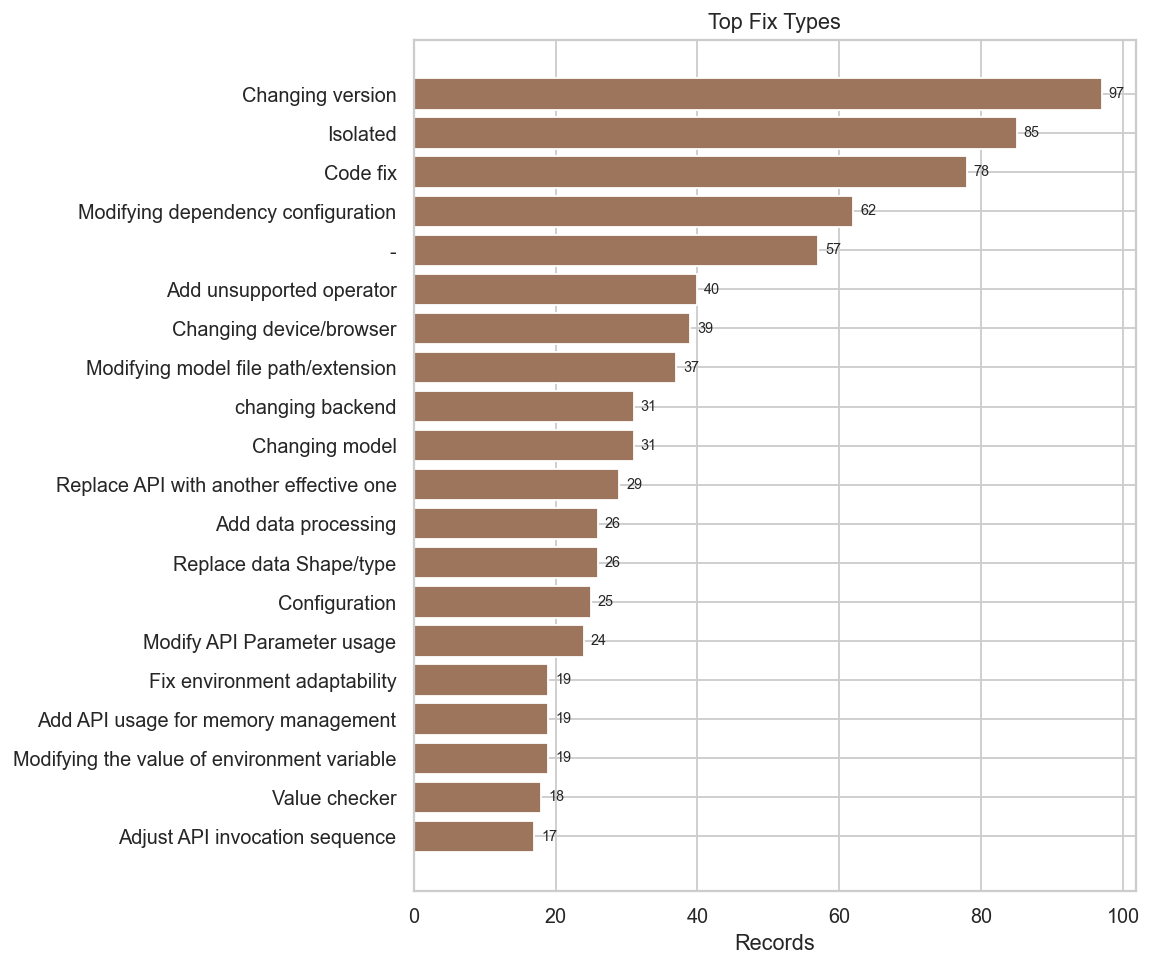

In [5]:
top_root = bar_count(df['root_cause'], 'Top Root Causes', '04_top_root_causes.png', top_n=20, color='#E45756')
top_symptom = bar_count(df['symptom'], 'Top Symptoms', '05_top_symptoms.png', top_n=20, color='#4C78A8')
top_bug_type = bar_count(df['bug_type'], 'Top Bug Types', '06_top_bug_types.png', top_n=15, color='#B279A2')
top_component = bar_count(df['component'], 'Top Components', '07_top_components.png', top_n=20, color='#59A14F')
top_fix = bar_count(df['fix_type'], 'Top Fix Types', '08_top_fix_types.png', top_n=20, color='#9D755D')

## 4. 来源 × 标签的联合分析

下面的热力图回答两个问题：

1. 某个来源主要贡献哪些 root cause / symptom？
2. 某些 root cause / symptom 是否只集中在单一来源，还是跨来源反复出现？

图中同时给出绝对数量和按来源归一化后的比例。

C:\Users\13726\AppData\Local\Temp\ipykernel_25632\4020199290.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


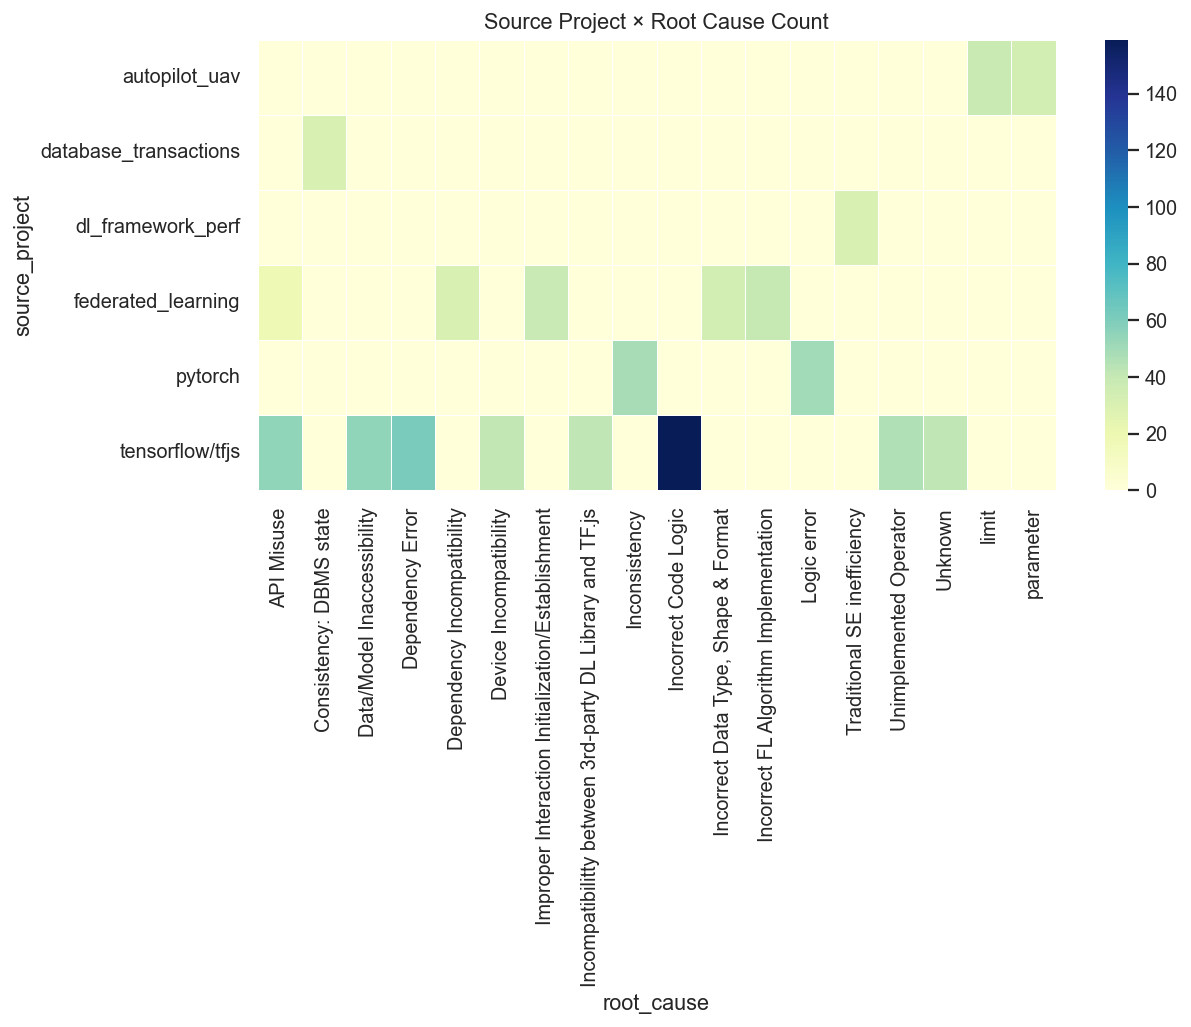

C:\Users\13726\AppData\Local\Temp\ipykernel_25632\4020199290.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


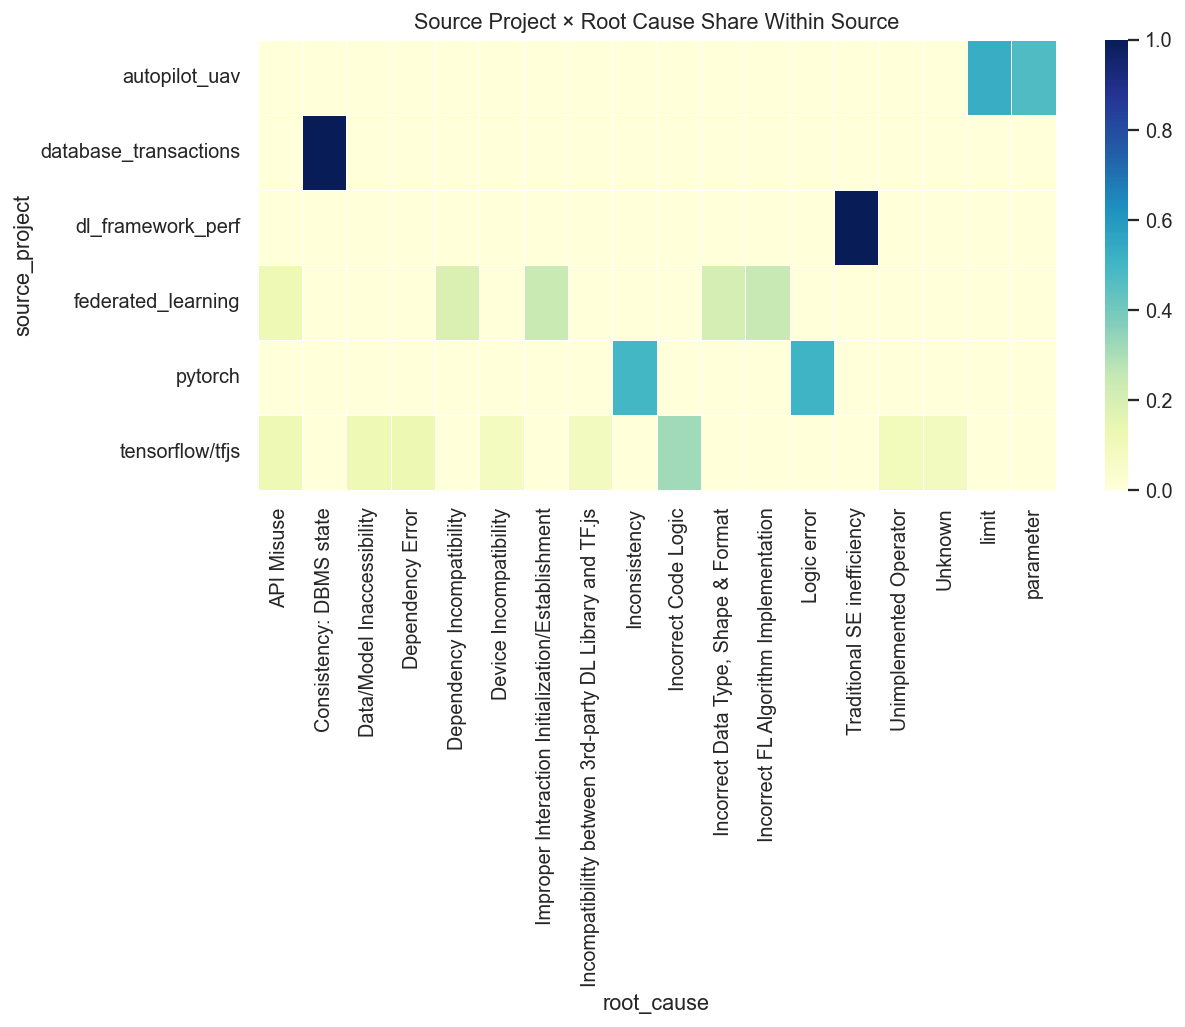

C:\Users\13726\AppData\Local\Temp\ipykernel_25632\4020199290.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


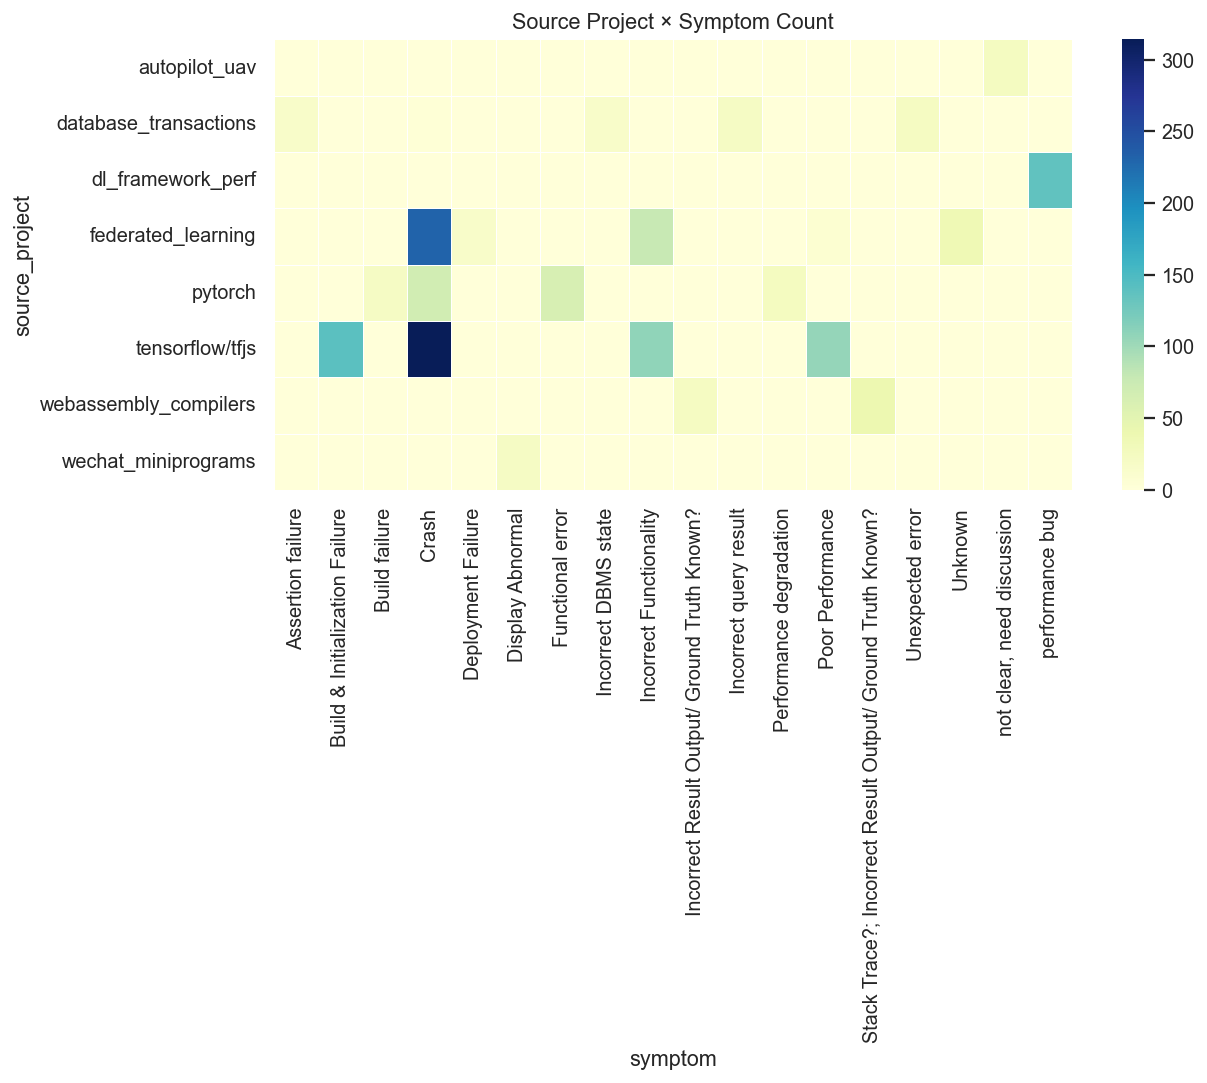

In [6]:
def top_values(column, n=15):
    return df.loc[nonempty(df[column]), column].value_counts().head(n).index.tolist()

def crosstab_heatmap(row_col, col_col, top_n=15, normalize=False, title='', filename='heatmap.png'):
    cols = top_values(col_col, top_n)
    sub = df[df[col_col].isin(cols) & nonempty(df[row_col])]
    table = pd.crosstab(sub[row_col], sub[col_col])
    if normalize:
        table = table.div(table.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fig, ax = plt.subplots(figsize=(max(9, 0.55 * table.shape[1]), max(4.5, 0.45 * table.shape[0])))
    if sns is not None:
        sns.heatmap(table, cmap='YlGnBu', linewidths=0.3, linecolor='white', ax=ax)
    else:
        im = ax.imshow(table.values, aspect='auto', cmap='YlGnBu')
        ax.set_xticks(range(table.shape[1]), table.columns, rotation=60, ha='right')
        ax.set_yticks(range(table.shape[0]), table.index)
        fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col_col)
    ax.set_ylabel(row_col)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, bbox_inches='tight')
    plt.show()
    return table

source_root_abs = crosstab_heatmap('source_project', 'root_cause', 18, False, 'Source Project × Root Cause Count', '09_source_root_cause_count.png')
source_root_norm = crosstab_heatmap('source_project', 'root_cause', 18, True, 'Source Project × Root Cause Share Within Source', '10_source_root_cause_share.png')
source_symptom_abs = crosstab_heatmap('source_project', 'symptom', 18, False, 'Source Project × Symptom Count', '11_source_symptom_count.png')

## 5. Root Cause × Symptom 联合分析

这一部分直接观察“原因-现象”组合。它适合用来发现高频 bug 模式，例如某类 root cause 是否稳定导致 crash、incorrect functionality、performance bug 等 symptom。

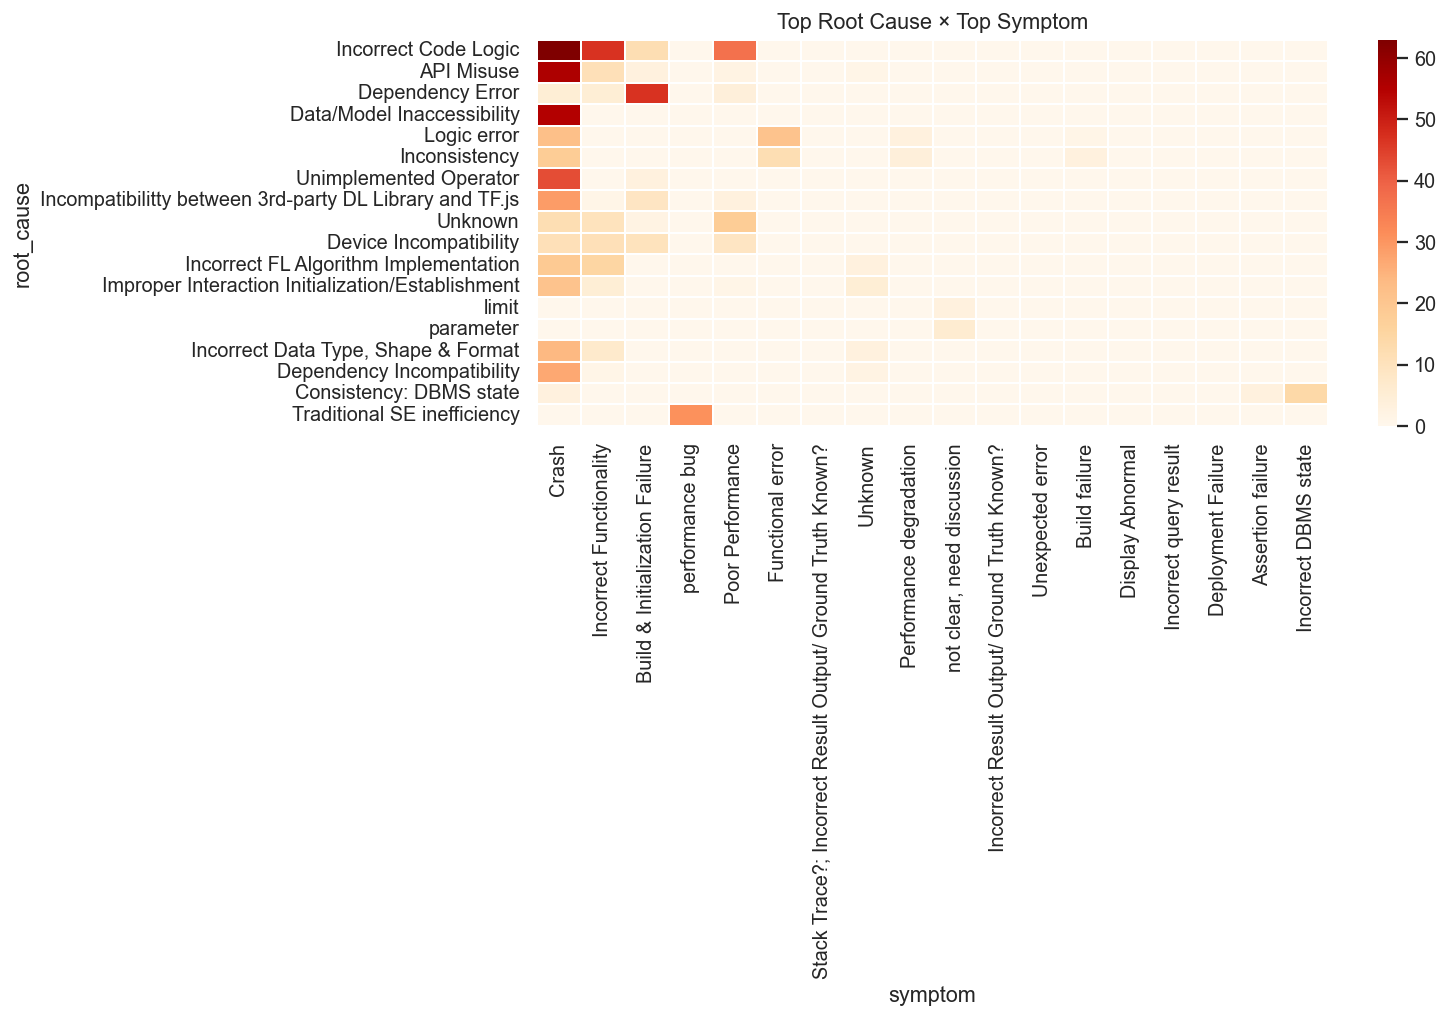

,root_cause,symptom,count
187,Incorrect Code Logic,Crash,63
33,API Misuse,Crash,56
93,Data/Model Inaccessibility,Crash,55
188,Incorrect Code Logic,Incorrect Functionality,47
94,Dependency Error,Build & Initialization Failure,47
325,Unimplemented Operator,Crash,43
189,Incorrect Code Logic,Poor Performance,37
317,Traditional SE inefficiency,performance bug,31
175,Incompatibilitty between 3rd-party DL Library ...,Crash,29
98,Dependency Incompatibility,Crash,27


In [7]:
root_symptom = pd.crosstab(
    df.loc[nonempty(df['root_cause']) & nonempty(df['symptom']), 'root_cause'],
    df.loc[nonempty(df['root_cause']) & nonempty(df['symptom']), 'symptom'],
)
top_roots = df.loc[nonempty(df['root_cause']), 'root_cause'].value_counts().head(18).index
top_symptoms = df.loc[nonempty(df['symptom']), 'symptom'].value_counts().head(18).index
root_symptom_top = root_symptom.reindex(index=top_roots, columns=top_symptoms).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 8))
if sns is not None:
    sns.heatmap(root_symptom_top, cmap='OrRd', linewidths=0.25, linecolor='white', ax=ax)
else:
    im = ax.imshow(root_symptom_top.values, aspect='auto', cmap='OrRd')
    ax.set_xticks(range(root_symptom_top.shape[1]), root_symptom_top.columns, rotation=60, ha='right')
    ax.set_yticks(range(root_symptom_top.shape[0]), root_symptom_top.index)
    fig.colorbar(im, ax=ax)
ax.set_title('Top Root Cause × Top Symptom')
fig.tight_layout()
fig.savefig(FIG_DIR / '12_root_cause_symptom_heatmap.png', bbox_inches='tight')
plt.show()

pair_counts = (
    df[nonempty(df['root_cause']) & nonempty(df['symptom'])]
    .groupby(['root_cause', 'symptom'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
pair_counts.head(30)

## 6. Bug Type / Component / Fix Type 的联合分析

这一部分关注标签之间的工程含义：不同 bug type 是否对应不同 root cause，不同 root cause 是否对应不同 fix type。

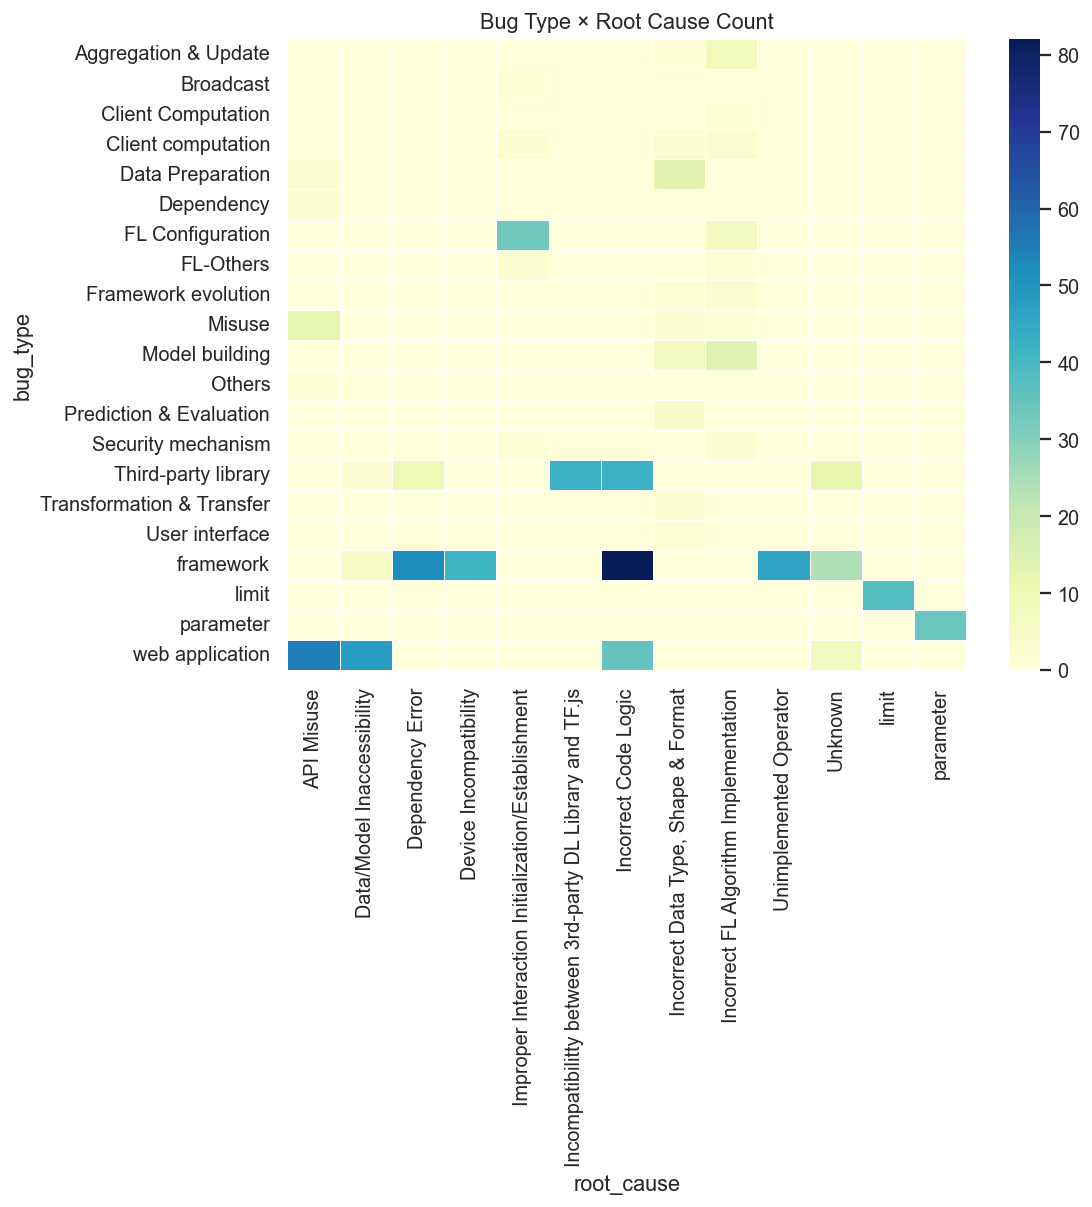

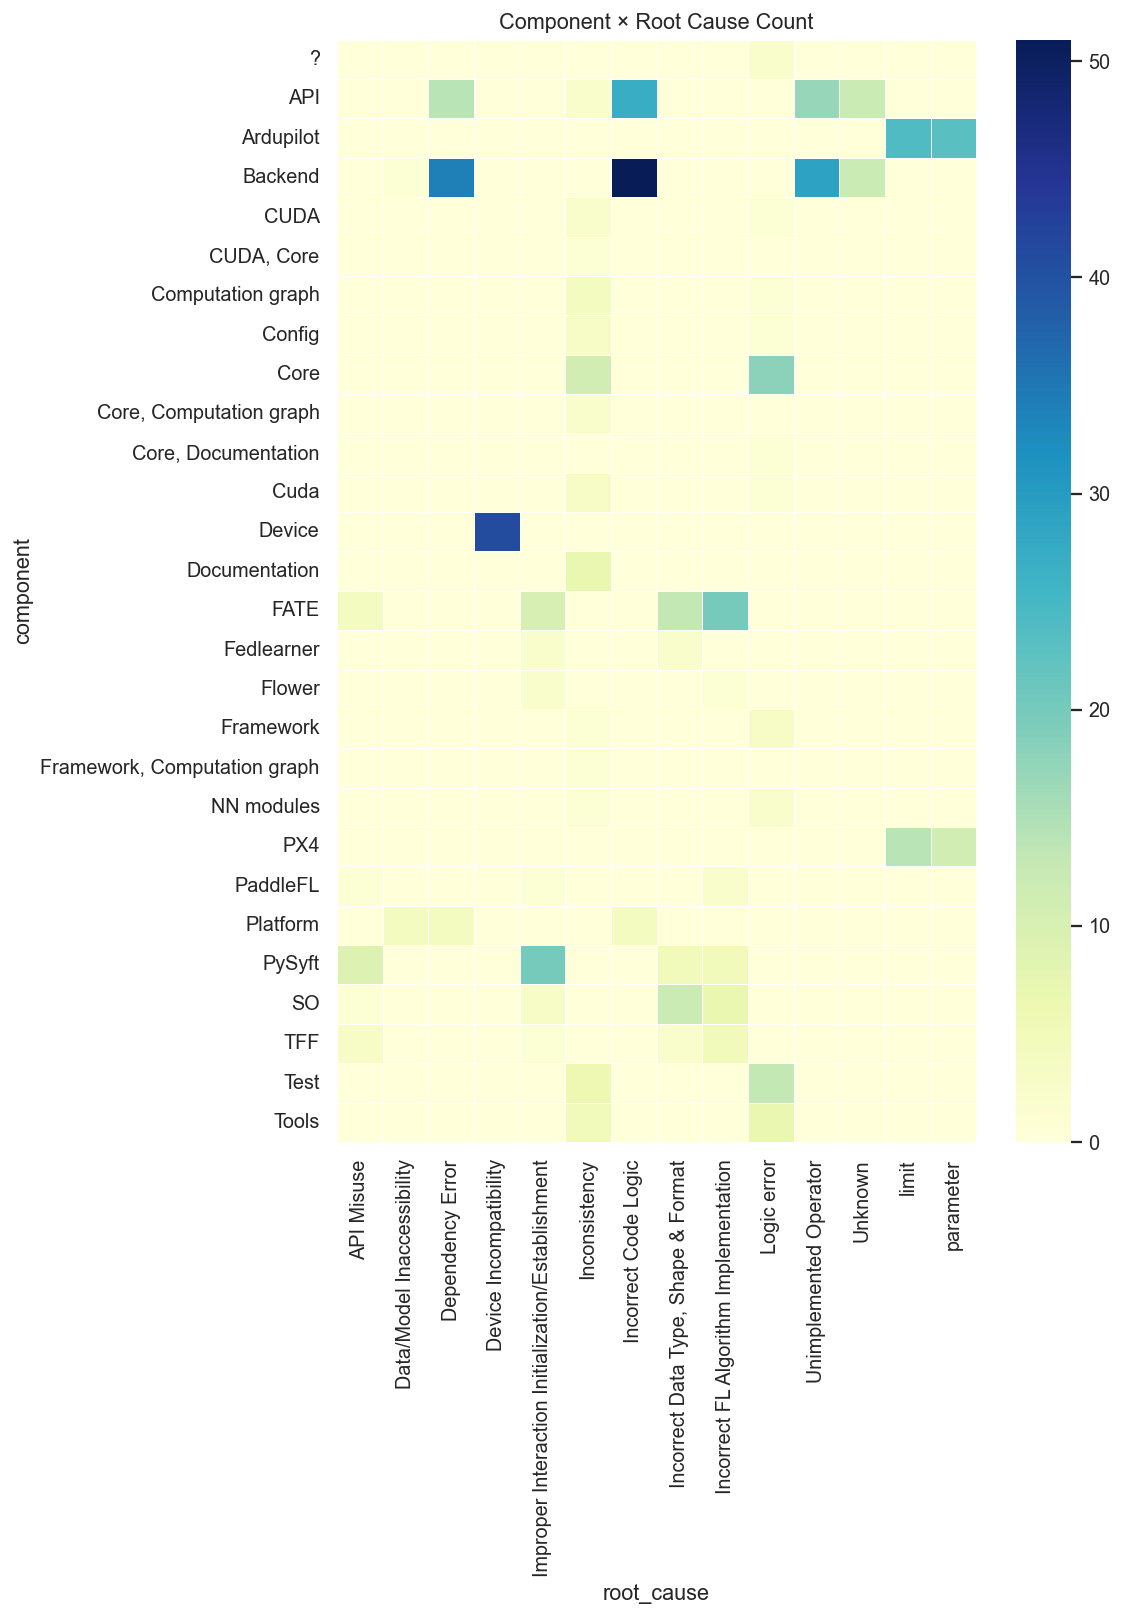

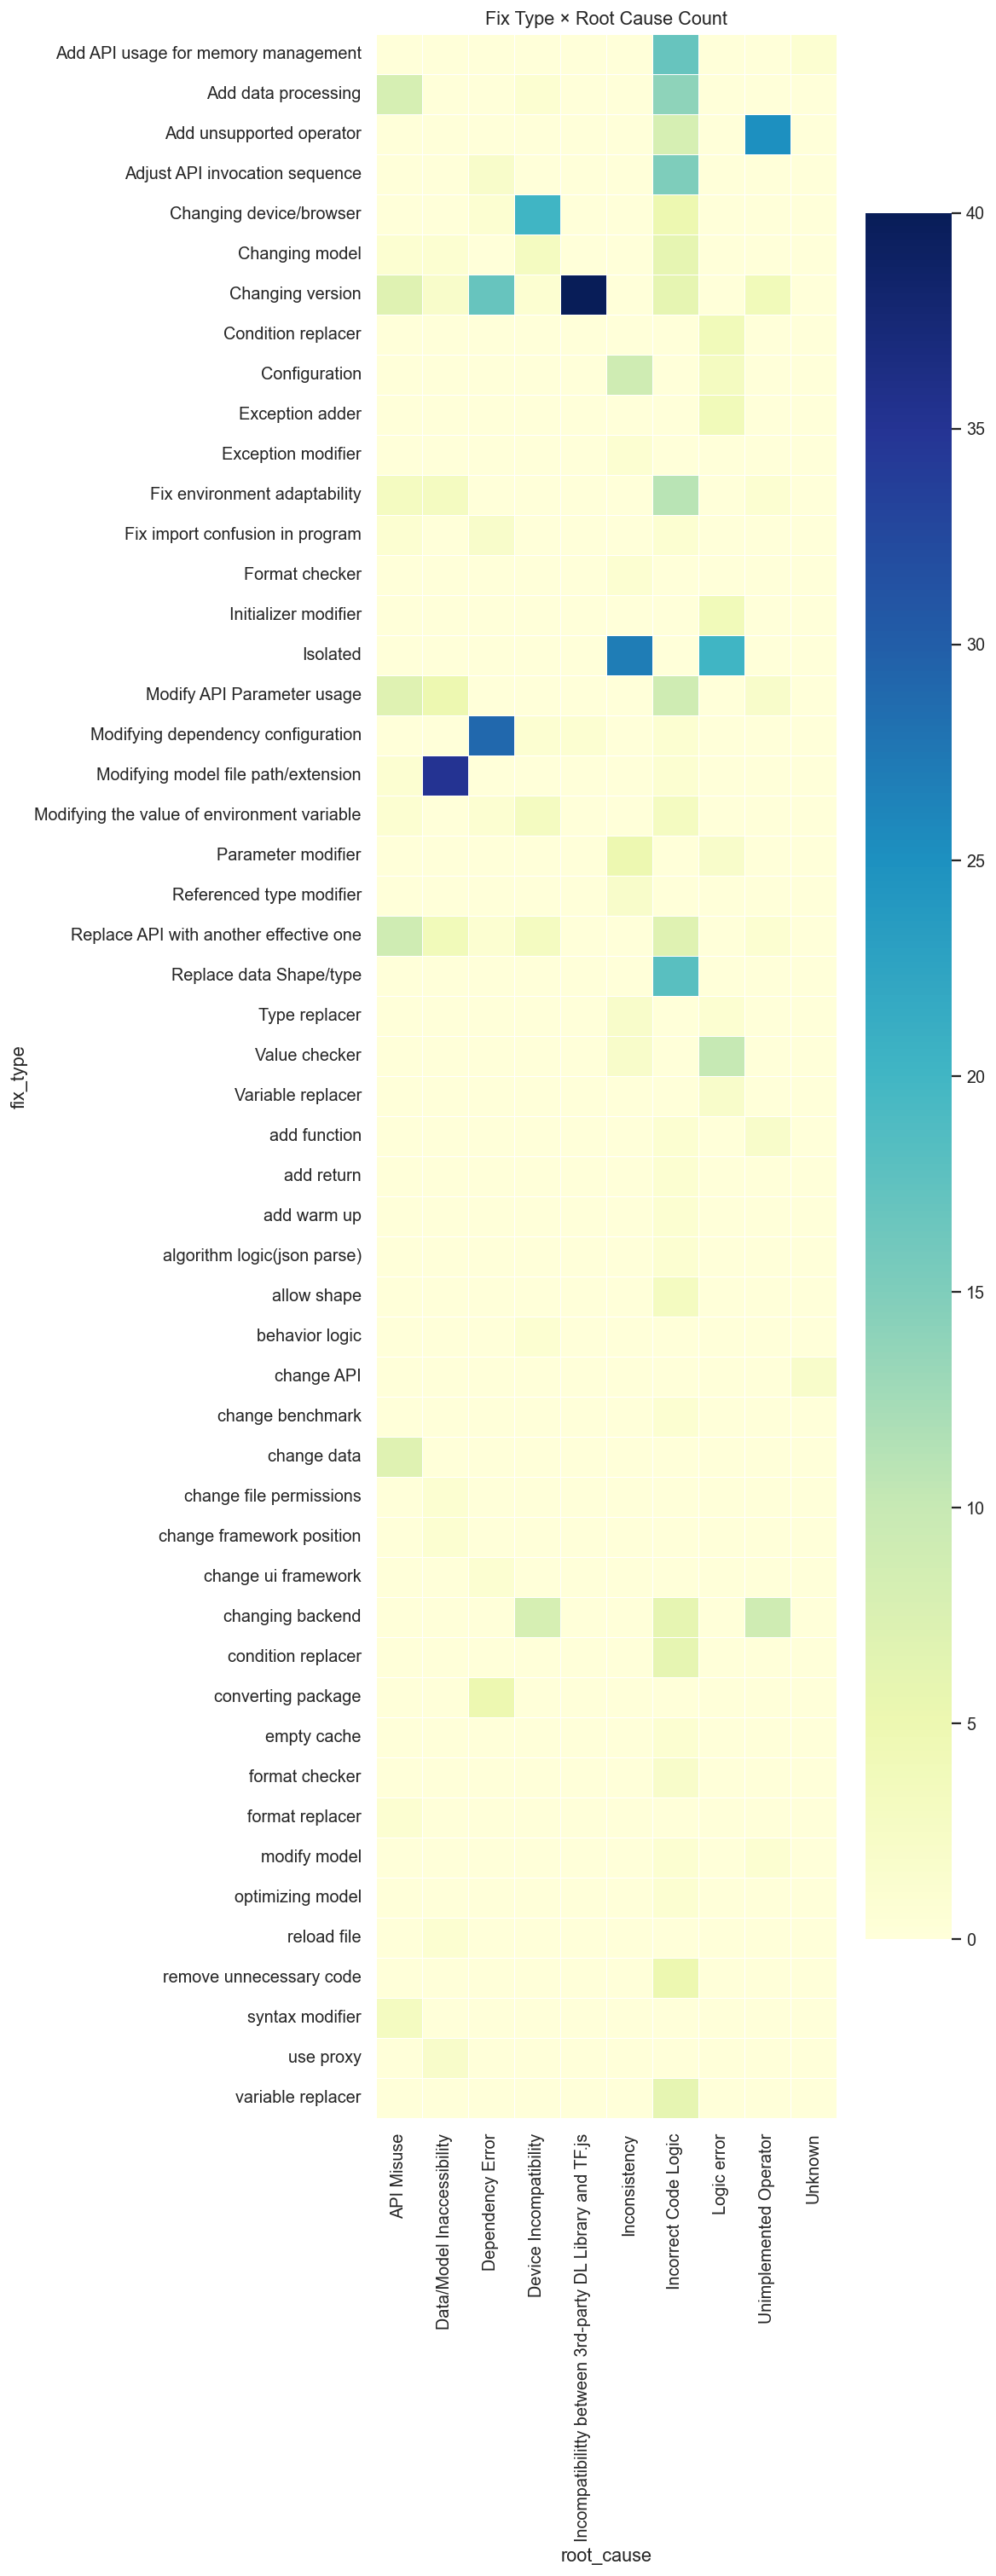

In [8]:
bugtype_root = crosstab_heatmap('bug_type', 'root_cause', 15, False, 'Bug Type × Root Cause Count', '13_bug_type_root_cause_count.png')
component_root = crosstab_heatmap('component', 'root_cause', 15, False, 'Component × Root Cause Count', '14_component_root_cause_count.png')
fix_root = crosstab_heatmap('fix_type', 'root_cause', 15, False, 'Fix Type × Root Cause Count', '15_fix_type_root_cause_count.png')

## 7. 来源多样性分析

如果某个来源的 root cause 或 symptom 高度集中，说明它更像单一主题数据集；如果分布更均匀，则说明它覆盖的问题类型更广。这里用 Shannon entropy 做一个简单量化。

,source_project,records,root_cause_unique,symptom_unique,root_cause_entropy,symptom_entropy
6,webassembly_compilers,146,109,11,6.554407,2.648229
3,federated_learning,395,30,9,4.495368,1.911620
2,dl_framework_perf,137,25,1,3.888621,-0.000000
5,tensorflow/tfjs,682,18,5,3.743129,1.932718
1,database_transactions,140,13,14,3.265792,3.432156
0,autopilot_uav,168,13,142,2.932741,6.700105
4,pytorch,194,11,6,2.850302,2.129235
7,wechat_miniprograms,45,5,4,2.148295,1.544803


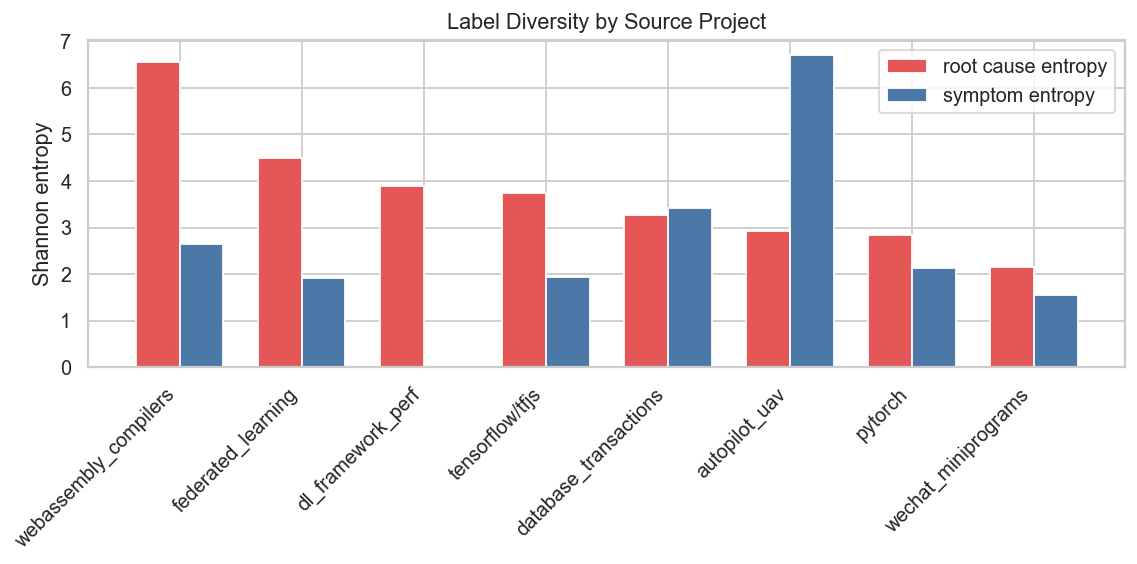

In [9]:
def entropy(values):
    counts = pd.Series(values)[pd.Series(values).astype(str).str.strip().ne('')].value_counts()
    if counts.empty:
        return 0.0
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())

diversity = []
for source, group in df.groupby('source_project'):
    diversity.append({
        'source_project': source,
        'records': len(group),
        'root_cause_unique': group.loc[nonempty(group['root_cause']), 'root_cause'].nunique(),
        'symptom_unique': group.loc[nonempty(group['symptom']), 'symptom'].nunique(),
        'root_cause_entropy': entropy(group['root_cause']),
        'symptom_entropy': entropy(group['symptom']),
    })

diversity_df = pd.DataFrame(diversity).sort_values('root_cause_entropy', ascending=False)
display(diversity_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(diversity_df))
ax.bar(x - 0.18, diversity_df['root_cause_entropy'], width=0.36, label='root cause entropy', color='#E45756')
ax.bar(x + 0.18, diversity_df['symptom_entropy'], width=0.36, label='symptom entropy', color='#4C78A8')
ax.set_xticks(x, diversity_df['source_project'], rotation=45, ha='right')
ax.set_ylabel('Shannon entropy')
ax.set_title('Label Diversity by Source Project')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '16_label_diversity_by_source.png', bbox_inches='tight')
plt.show()

## 8. 自动生成报告摘要

下面的单元格会根据当前数据生成一段可直接复制到报告里的中文摘要。

In [10]:
def top_items(column, n=5):
    counts = df.loc[nonempty(df[column]), column].value_counts().head(n)
    return '；'.join([f'{idx}（{val}）' for idx, val in counts.items()])

summary_lines = [
    f"本阶段统一数据集共包含 {len(df)} 条人工标注记录，来自 {df['source_project'].nunique()} 个 source project、{df['paper_id'].nunique()} 篇论文。",
    f"root_cause 字段覆盖 {nonempty(df['root_cause']).sum()}/{len(df)} 条记录，symptom 字段覆盖 {nonempty(df['symptom']).sum()}/{len(df)} 条记录。",
    f"数据量最大的来源是：{top_items('source_project', 5)}。",
    f"最高频 root cause 是：{top_items('root_cause', 8)}。",
    f"最高频 symptom 是：{top_items('symptom', 8)}。",
    f"最高频 bug type 是：{top_items('bug_type', 8)}。",
    f"最高频 component 是：{top_items('component', 8)}。",
    "联合分析建议优先查看：source_project × root_cause、root_cause × symptom、bug_type × root_cause 三组图，因为它们最能反映不同论文数据集之间的标签口径差异和跨来源共性。",
]

report = '\n\n'.join(summary_lines)
print(report)

report_path = FIG_DIR / 'stage1_visual_analysis_summary.md'
report_path.write_text('# Stage1 Visual Analysis Summary\n\n' + report + '\n', encoding='utf-8')
print(f'\nWrote: {report_path}')

本阶段统一数据集共包含 1907 条人工标注记录，来自 8 个 source project、8 篇论文。

root_cause 字段覆盖 1907/1907 条记录，symptom 字段覆盖 1869/1907 条记录。

数据量最大的来源是：tensorflow/tfjs（682）；federated_learning（395）；pytorch（194）；autopilot_uav（168）；webassembly_compilers（146）。

最高频 root cause 是：Incorrect Code Logic（159）；API Misuse（73）；Dependency Error（61）；Data/Model Inaccessibility（55）；Logic error（50）；Inconsistency（49）；Unimplemented Operator（46）；Incompatibilitty between 3rd-party DL Library and TF.js（42）。

最高频 symptom 是：Crash（616）；Incorrect Functionality（186）；Build & Initialization Failure（141）；performance bug（137）；Poor Performance（114）；Functional error（62）；Stack Trace?; Incorrect Result Output/ Ground Truth Known?（40）；Unknown（36）。

最高频 bug type 是：framework（378）；web application（180）；performance bug（137）；Third-party library（124）；Model building（46）；FL Configuration（46）；GitHub/Issue（45）；Data Preparation（44）。

最高频 component 是：Backend（180）；PySyft（129）；FATE（125）；Ardupilot（103）；API（102）；Pytorch（95）；Core（72）；PX4（65）。

联合分析建议优先查看：source_proje

## 9. 导出表格结果

除图片外，也导出若干 CSV，方便后续人工检查或写论文时引用具体数值。

In [11]:
quality_df.to_csv(FIG_DIR / 'quality_summary.csv', index=False, encoding='utf-8-sig')
source_counts.rename('count').to_csv(FIG_DIR / 'source_project_counts.csv', encoding='utf-8-sig')
top_root.rename('count').to_csv(FIG_DIR / 'top_root_causes.csv', encoding='utf-8-sig')
top_symptom.rename('count').to_csv(FIG_DIR / 'top_symptoms.csv', encoding='utf-8-sig')
pair_counts.to_csv(FIG_DIR / 'root_cause_symptom_pairs.csv', index=False, encoding='utf-8-sig')
diversity_df.to_csv(FIG_DIR / 'source_label_diversity.csv', index=False, encoding='utf-8-sig')

print(f'Exported figures and tables to: {FIG_DIR}')

Exported figures and tables to: D:\AutoEmpirical-Reproduce\data\processed\stage1_visuals
